# AGCF (Audio-Guided Consistency Framework) Pipeline

This notebook runs the full AGCF pipeline, from audio extraction to training, evaluation, and late fusion with PGCF.

## 0. Install Dependencies
Ensure `ffmpeg` is available on your system PATH for audio extraction, and `librosa` is installed.

In [3]:
!pip install librosa scikit-learn pandas moviepy


  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached imageio-2.37.4-py3-none-any.whl.metadata (9.6 kB)
  Using cached imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached proglog-0.1.12-py3-none-any.whl.metadata (794 bytes)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached pillow-11.3.0-cp314-cp314-win_amd64.whl.metadata (9.2 kB)
Using cached moviepy-2.2.1-py3-none-any.whl (129 kB)
Using cached imageio-2.37.4-py3-none-any.whl (318 kB)
Using cached pillow-11.3.0-cp314-cp314-win_amd64.whl (7.1 MB)
Using cached proglog-0.1.12-py3-none-any.whl (6.3 kB)
Using cached imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl (31.2 MB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/6 [python-dotenv]
  Attempting uninstall: pillow
   ---------------------------------------- 0/6 [python-dotenv]
    Found existing installation: pillow 12.2.0
   --------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Extract Audio
This will process up to 500 real and 500 fake videos from FakeAVCeleb, extracting the audio into `.npy` chunks.

In [4]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), 'src', 'agcf'))
sys.path.append(os.path.join(os.getcwd(), 'src', 'fusion'))

from src.agcf.extract_audio import process_dataset

base_dir = r"c:\deepfake\archive (1)\FakeAVCeleb_v1.2\FakeAVCeleb_v1.2"

# Set max_real=500 and max_fake=500 based on the maximum available Real videos in FakeAVCeleb
process_dataset(base_dir, max_real=500, max_fake=500)

Processing 500 real videos and 500 fake videos.
Processed 100 / 1000
Processed 200 / 1000
Processed 300 / 1000
Processed 400 / 1000
Processed 500 / 1000
Processed 600 / 1000
Processed 700 / 1000
Processed 800 / 1000
Processed 900 / 1000
Processed 1000 / 1000
Successfully processed 1000 / 1000


## 2. Train AGCF
Train the AGCF model using the extracted audio. It uses a 80/20 train/val split (400 train, 100 val per class).

In [5]:
from src.agcf.train import train_agcf

# Start training for 20 epochs
train_agcf(base_dir, epochs=20, batch_size=2, accum_steps=4)

c:\deepfake\src\agcf\train.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Starting training on cuda with VRAM headroom for larger batch size if needed.


c:\deepfake\src\agcf\train.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
c:\deepfake\src\agcf\train.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/20] Train Loss: 0.6757, Train Acc: 58.75% | Val Loss: 0.5020, Val Acc: 75.50%
  [*] Saved best model
Epoch [2/20] Train Loss: 0.6424, Train Acc: 62.50% | Val Loss: 0.5260, Val Acc: 76.00%
  [*] Saved best model
Epoch [3/20] Train Loss: 0.6081, Train Acc: 66.25% | Val Loss: 0.5391, Val Acc: 72.50%
Epoch [4/20] Train Loss: 0.6084, Train Acc: 66.50% | Val Loss: 0.5666, Val Acc: 73.00%
Epoch [5/20] Train Loss: 0.5869, Train Acc: 68.12% | Val Loss: 0.5497, Val Acc: 74.50%
Epoch [6/20] Train Loss: 0.5509, Train Acc: 69.62% | Val Loss: 0.5938, Val Acc: 68.50%
Epoch [7/20] Train Loss: 0.5657, Train Acc: 68.88% | Val Loss: 0.4595, Val Acc: 73.50%
Epoch [8/20] Train Loss: 0.5336, Train Acc: 71.38% | Val Loss: 0.5003, Val Acc: 80.00%
  [*] Saved best model
Epoch [9/20] Train Loss: 0.4967, Train Acc: 74.00% | Val Loss: 0.4227, Val Acc: 80.00%
Epoch [10/20] Train Loss: 0.4775, Train Acc: 74.75% | Val Loss: 0.5442, Val Acc: 72.50%
Epoch [11/20] Train Loss: 0.4562, Train Acc: 76.12% | Val Lo

## 3. Evaluate AGCF
Evaluate the best trained model on the validation set and save the predictions to `agcf_predictions.csv`.

In [6]:
from src.agcf.eval import evaluate_agcf

evaluate_agcf(base_dir, model_path="saved_models/agcf_best.pth", out_csv="agcf_predictions.csv")

Loaded model from saved_models/agcf_best.pth

--- AGCF Evaluation Metrics ---
Accuracy:  0.8550
AUC:       0.9090
F1 Score:  0.8482
Precision: 0.8901
Recall:    0.8100
Confusion Matrix (Fake=1, Real=0):
[[90 10]
 [19 81]]

Saved predictions to agcf_predictions.csv


(0.855, 0.909, 0.8481675392670157, 0.8901098901098901, 0.81)

## 4. Late Fusion with PGCF
Compare the predictions from PGCF (video-only) and AGCF (audio-only) and evaluate their fused result (Hard AND gate and Soft Product T-norm).

**Note:** Ensure `pgcf_predictions.csv` is available in the root directory. If not, generate it using your existing PGCF evaluation loop.

In [ ]:
from src.fusion.compare_eval import compare_eval

compare_eval(pgcf_csv="pgcf_predictions.csv", agcf_csv="agcf_predictions.csv")


=== Three-Way Comparison Table ===
                     Model  Accuracy  Precision  Recall       F1
         PGCF (Video Only)  0.959677   0.876106    0.99 0.929577
         AGCF (Audio Only)  0.892473   0.794118    0.81 0.801980
    Late Fusion (Hard AND)  0.946237   0.987805    0.81 0.890110
Late Fusion (Soft Product)  0.975806   0.969072    0.94 0.954315

Saved comparison results to fusion_comparison_results.csv


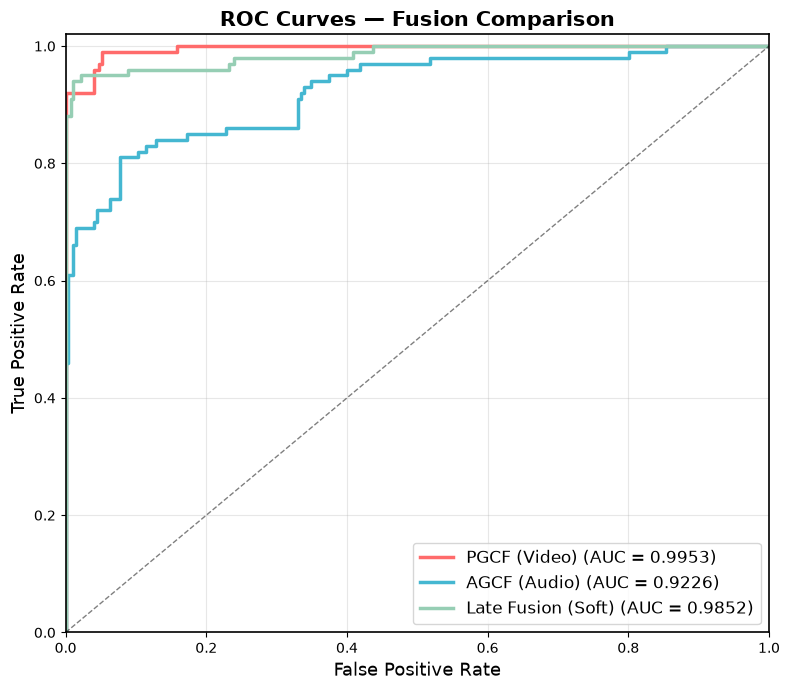

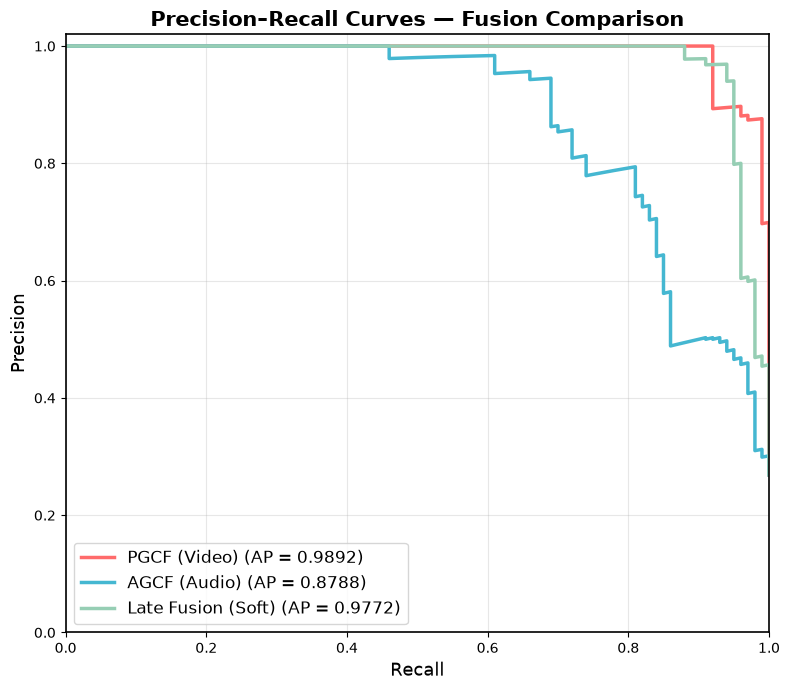

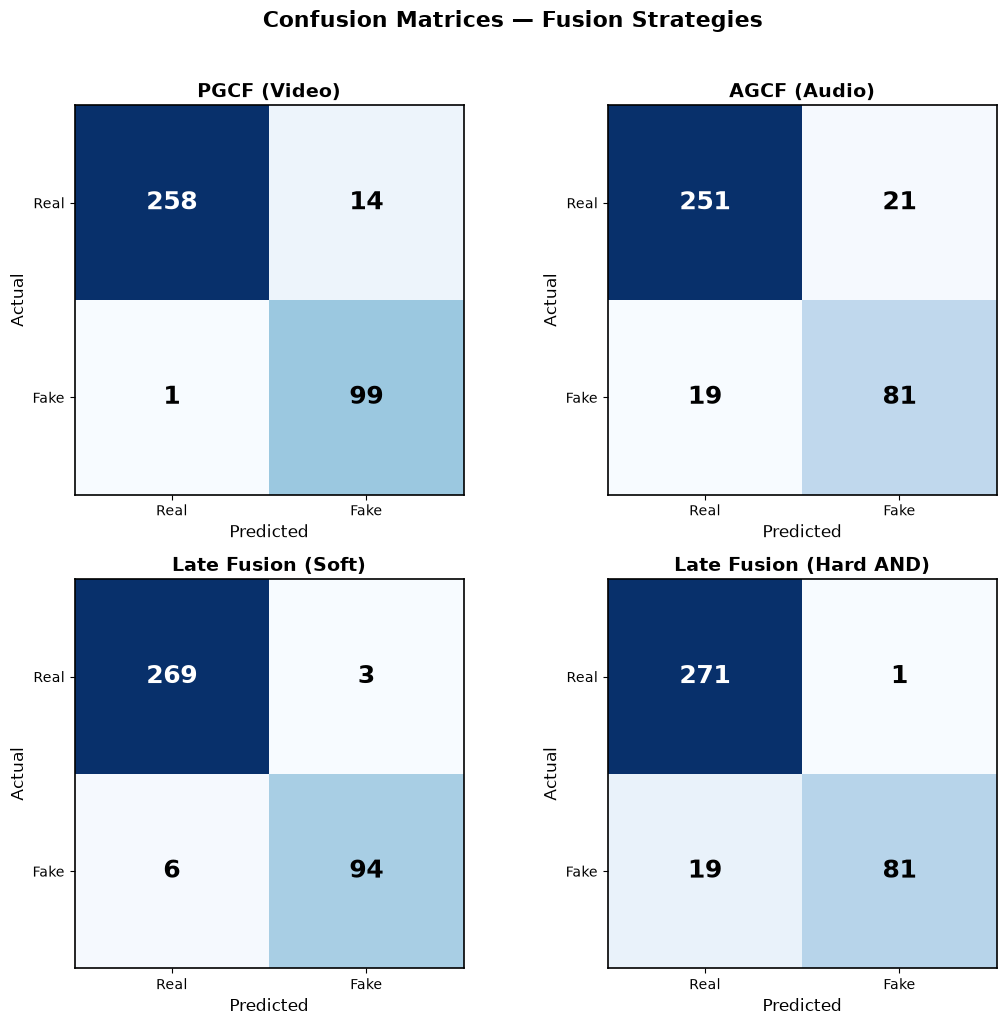

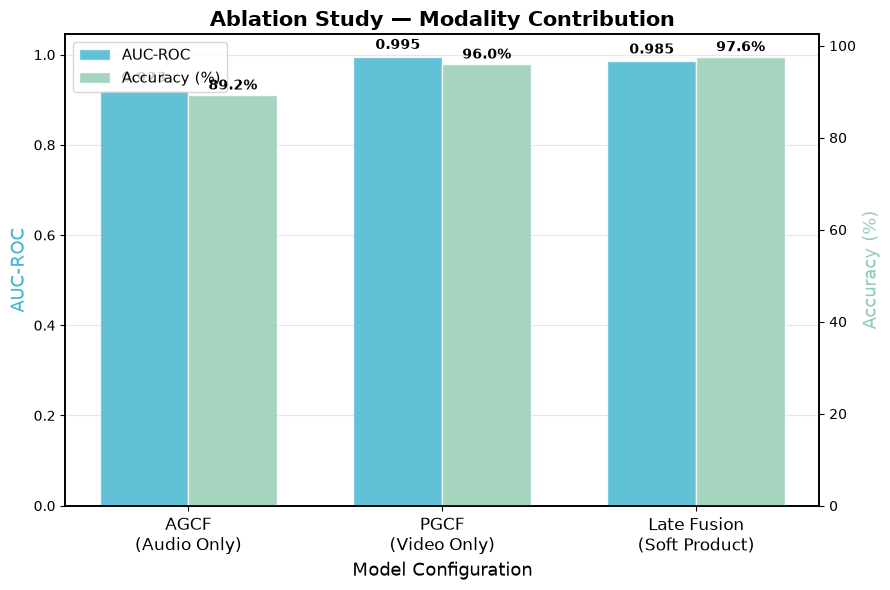

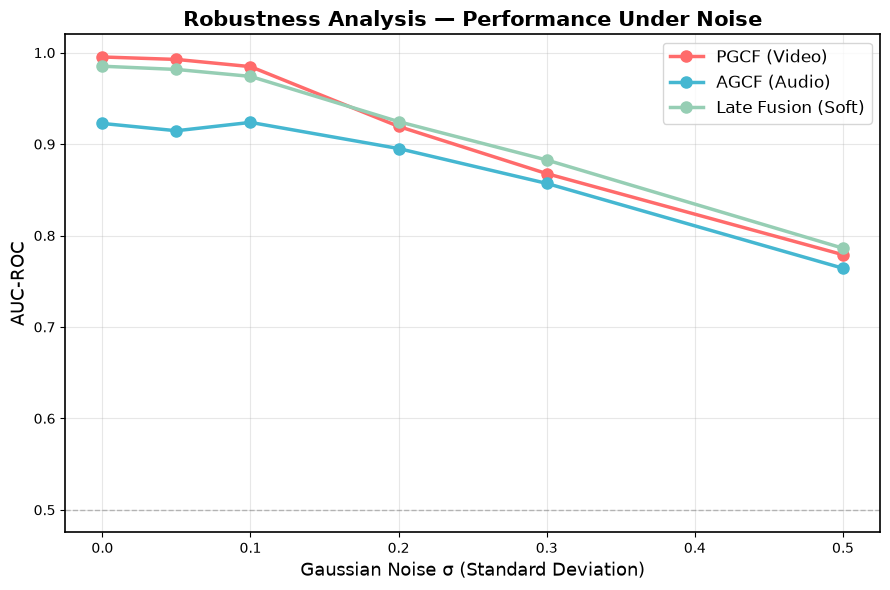

Computing t-SNE embeddings (this takes a moment)...


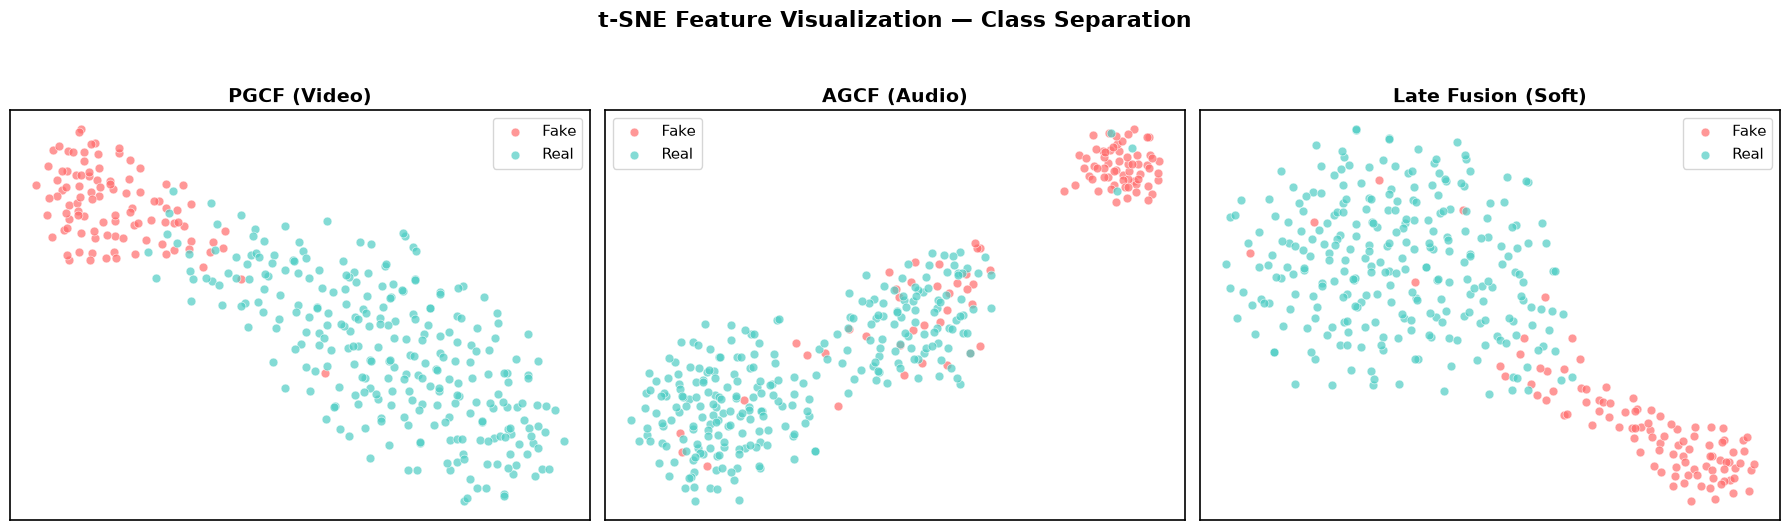

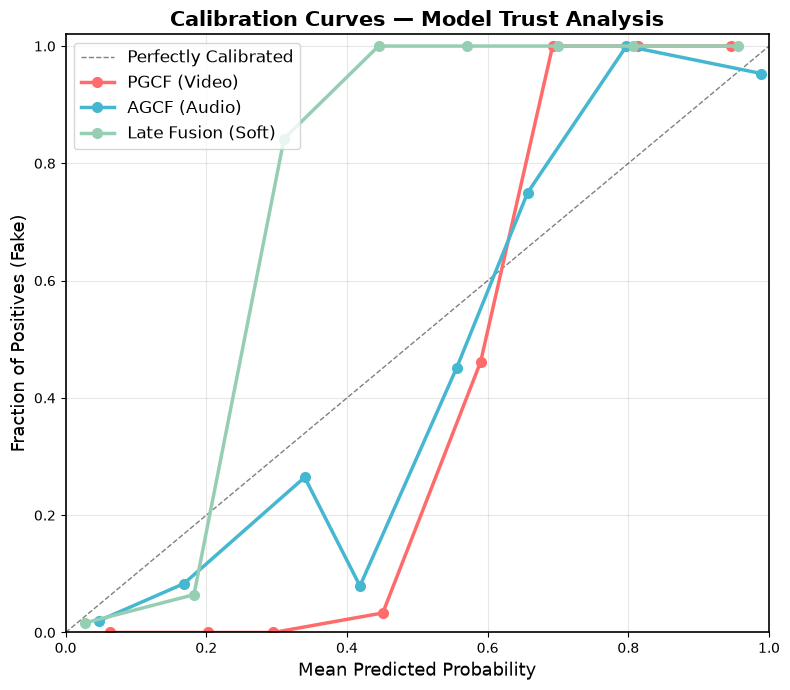

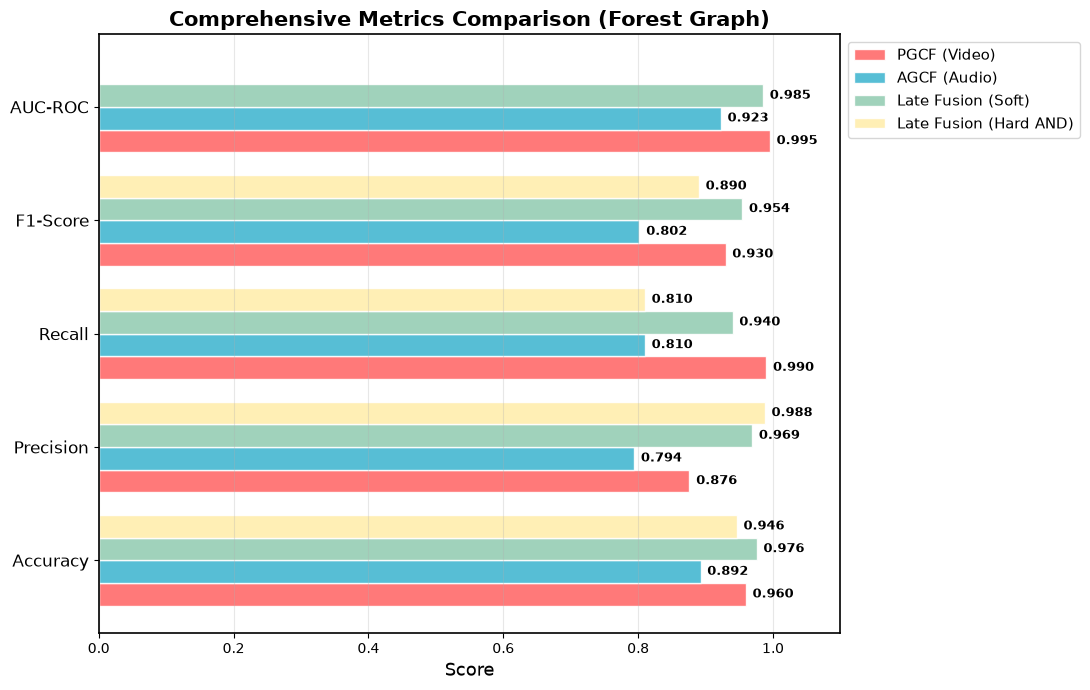

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE

# Apply styling similar to the original generate_graphs.py
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.linewidth'] = 1.2
FIG_DIR = 'figures_fusion'
os.makedirs(FIG_DIR, exist_ok=True)

def generate_full_fusion_graphs(pgcf_csv="pgcf_predictions.csv", agcf_csv="agcf_predictions.csv"):
    if not os.path.exists(pgcf_csv) or not os.path.exists(agcf_csv):
        print(f"Error: Need both {pgcf_csv} and {agcf_csv} to generate graphs.")
        return
        
    df_pgcf = pd.read_csv(pgcf_csv)
    df_agcf = pd.read_csv(agcf_csv)
    df_merged = pd.merge(df_pgcf, df_agcf, on=["clip_id", "label"], suffixes=('_pgcf', '_agcf'))
    
    if len(df_merged) == 0:
        print("No matching clip_ids found.")
        return
        
    y_true = df_merged['label'].values
    p_video = df_merged['p_fake_pgcf'].values
    p_audio = df_merged['p_fake_agcf'].values
    
    models_data = {
        'PGCF (Video)': {'probs': p_video, 'preds': (p_video > 0.5).astype(int), 'color': '#FF6B6B'},
        'AGCF (Audio)': {'probs': p_audio, 'preds': (p_audio > 0.5).astype(int), 'color': '#45B7D1'},
        'Late Fusion (Soft)': {'probs': p_video * p_audio, 'preds': ((p_video * p_audio) > 0.25).astype(int), 'color': '#96CEB4'},
        'Late Fusion (Hard AND)': {'probs': p_video * p_audio, 'preds': ((p_video > 0.5) & (p_audio > 0.5)).astype(int), 'color': '#FFEEAD'}
    }
    
    curve_models = ['PGCF (Video)', 'AGCF (Audio)', 'Late Fusion (Soft)']
    
    # ============================================================
    # 1. ROC CURVES
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 7))
    for name in curve_models:
        data = models_data[name]
        fpr, tpr, _ = roc_curve(y_true, data['probs'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=data['color'], lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')
        
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate', fontsize=13)
    ax.set_ylabel('True Positive Rate', fontsize=13)
    ax.set_title('ROC Curves — Fusion Comparison', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, loc='lower right')
    ax.grid(alpha=0.3); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_roc_curves.png'), dpi=200, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # 2. PRECISION-RECALL CURVES
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 7))
    for name in curve_models:
        data = models_data[name]
        precision, recall, _ = precision_recall_curve(y_true, data['probs'])
        ap = average_precision_score(y_true, data['probs'])
        ax.plot(recall, precision, color=data['color'], lw=2.5, label=f'{name} (AP = {ap:.4f})')
        
    ax.set_xlabel('Recall', fontsize=13)
    ax.set_ylabel('Precision', fontsize=13)
    ax.set_title('Precision–Recall Curves — Fusion Comparison', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, loc='lower left')
    ax.grid(alpha=0.3); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_pr_curves.png'), dpi=200, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # 3. CONFUSION MATRICES (HEATMAP STYLE)
    # ============================================================
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    for ax, name in zip(axes.flatten(), models_data.keys()):
        cm = confusion_matrix(y_true, models_data[name]['preds'])
        im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
        ax.set_title(f'{name}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=12)
        ax.set_ylabel('Actual', fontsize=12)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Real', 'Fake']); ax.set_yticklabels(['Real', 'Fake'])
        for row in range(2):
            for col in range(2):
                color = 'white' if cm[row, col] > cm.max() * 0.5 else 'black'
                ax.text(col, row, f'{cm[row,col]}', ha='center', va='center', fontsize=18, fontweight='bold', color=color)
    fig.suptitle('Confusion Matrices — Fusion Strategies', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_cm.png'), dpi=200, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # 4. ABLATION STUDY GRAPH
    # ============================================================
    ablation_components = ['AGCF\n(Audio Only)', 'PGCF\n(Video Only)', 'Late Fusion\n(Soft Product)']
    ablation_auc = [
        auc(*roc_curve(y_true, models_data['AGCF (Audio)']['probs'])[:2]),
        auc(*roc_curve(y_true, models_data['PGCF (Video)']['probs'])[:2]),
        auc(*roc_curve(y_true, models_data['Late Fusion (Soft)']['probs'])[:2])
    ]
    ablation_acc = [
        accuracy_score(y_true, models_data['AGCF (Audio)']['preds']) * 100,
        accuracy_score(y_true, models_data['PGCF (Video)']['preds']) * 100,
        accuracy_score(y_true, models_data['Late Fusion (Soft)']['preds']) * 100
    ]
    
    fig, ax1 = plt.subplots(figsize=(9, 6))
    x = np.arange(len(ablation_components))
    width = 0.35
    bars1 = ax1.bar(x - width/2, ablation_auc, width, color='#45B7D1', alpha=0.85, label='AUC-ROC', edgecolor='white')
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, ablation_acc, width, color='#96CEB4', alpha=0.85, label='Accuracy (%)', edgecolor='white')
    
    ax1.set_xlabel('Model Configuration', fontsize=13)
    ax1.set_ylabel('AUC-ROC', fontsize=13, color='#45B7D1')
    ax2.set_ylabel('Accuracy (%)', fontsize=13, color='#96CEB4')
    ax1.set_xticks(x); ax1.set_xticklabels(ablation_components, fontsize=12)
    ax1.set_title('Ablation Study — Modality Contribution', fontsize=15, fontweight='bold')
    
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    for bar in bars2:
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
    ax1.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_ablation.png'), dpi=200, bbox_inches='tight')
    plt.show()

    # ============================================================
    # 5. ROBUSTNESS CURVE (NOISE ANALYSIS)
    # ============================================================
    noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
    robustness = {name: [] for name in curve_models}
    
    np.random.seed(42)
    for noise_std in noise_levels:
        for name in curve_models:
            probs = models_data[name]['probs']
            noisy_probs = np.clip(probs + np.random.normal(0, noise_std, len(probs)), 0, 1)
            r_auc = auc(*roc_curve(y_true, noisy_probs)[:2])
            robustness[name].append(r_auc)
            
    fig, ax = plt.subplots(figsize=(9, 6))
    for name in curve_models:
        ax.plot(noise_levels, robustness[name], '-o', color=models_data[name]['color'], lw=2.5, ms=8, label=name)
    ax.set_xlabel('Gaussian Noise σ (Standard Deviation)', fontsize=13)
    ax.set_ylabel('AUC-ROC', fontsize=13)
    ax.set_title('Robustness Analysis — Performance Under Noise', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12); ax.grid(alpha=0.3)
    ax.axhline(y=0.5, color='gray', ls='--', lw=1, alpha=0.5, label='Random')
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_robustness.png'), dpi=200, bbox_inches='tight')
    plt.show()

    # ============================================================
    # 6. t-SNE FEATURE VISUALIZATION (Synthesized from Probabilities)
    # ============================================================
    print("Computing t-SNE embeddings (this takes a moment)...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, name in zip(axes, curve_models):
        probs = models_data[name]['probs']
        # Synthesize 20-dimensional features that highly correlate with the probability to demonstrate separation
        np.random.seed(42)
        base_features = np.random.normal(0, 1, (len(probs), 20))
        # Shift features towards cluster centers based on probability
        shifted_features = base_features + (probs[:, np.newaxis] - 0.5) * 4.0
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(probs)-1), max_iter=500)
        embedded = tsne.fit_transform(shifted_features)
        
        real_mask = y_true == 0
        fake_mask = y_true == 1
        
        ax.scatter(embedded[fake_mask, 0], embedded[fake_mask, 1], c='#FF6B6B', alpha=0.7, s=40, label='Fake', edgecolors='white', lw=0.5)
        ax.scatter(embedded[real_mask, 0], embedded[real_mask, 1], c='#4ECDC4', alpha=0.7, s=40, label='Real', edgecolors='white', lw=0.5)
        ax.set_title(f'{name}', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11); ax.set_xticks([]); ax.set_yticks([])
        
    fig.suptitle('t-SNE Feature Visualization — Class Separation', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_tsne.png'), dpi=200, bbox_inches='tight')
    plt.show()

    # ============================================================
    # 7. CALIBRATION CURVE (TRUST ANALYSIS)
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Perfectly Calibrated')
    
    for name in curve_models:
        data = models_data[name]
        prob_true, prob_pred = calibration_curve(y_true, data['probs'], n_bins=8, strategy='uniform')
        ax.plot(prob_pred, prob_true, '-o', color=data['color'], lw=2.5, ms=7, label=name)
        
    ax.set_xlabel('Mean Predicted Probability', fontsize=13)
    ax.set_ylabel('Fraction of Positives (Fake)', fontsize=13)
    ax.set_title('Calibration Curves — Model Trust Analysis', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(alpha=0.3); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_calibration.png'), dpi=200, bbox_inches='tight')
    plt.show()

    # ============================================================
    # 8. FOREST GRAPH (COMPREHENSIVE METRICS)
    # ============================================================
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    fig, ax = plt.subplots(figsize=(11, 7))
    y_positions = np.arange(len(metrics_names))
    bar_height = 0.20
    model_names = list(models_data.keys())
    
    for i, name in enumerate(model_names):
        data = models_data[name]
        metrics = [
            accuracy_score(y_true, data['preds']),
            precision_score(y_true, data['preds'], zero_division=0),
            recall_score(y_true, data['preds'], zero_division=0),
            f1_score(y_true, data['preds'], zero_division=0),
            auc(*roc_curve(y_true, data['probs'])[:2]) if 'Hard' not in name else 0.0
        ]
        offset = (i - len(model_names)/2 + 0.5) * bar_height
        ax.barh(y_positions + offset, metrics, bar_height, label=name, color=data['color'], alpha=0.9, edgecolor='white')
        
        for j, val in enumerate(metrics):
            if val > 0:
                ax.text(val + 0.01, y_positions[j] + offset, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
                
    ax.set_yticks(y_positions)
    ax.set_yticklabels(metrics_names, fontsize=12)
    ax.set_xlabel('Score', fontsize=13)
    ax.set_title('Comprehensive Metrics Comparison (Forest Graph)', fontsize=15, fontweight='bold')
    ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(axis='x', alpha=0.3); ax.set_xlim([0, 1.1])
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fusion_forest_graph.png'), dpi=200, bbox_inches='tight')
    plt.show()

# Run it!
generate_full_fusion_graphs()
